In [183]:
"""
Create or download a time series dataset with continuous labels 
and train RNNs and deep RNNs for one-step ahead and multiple-step ahead forecasting.

"""

import sys
assert sys.version_info >= (3, 5)

# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. LSTMs and CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")


No GPU was detected. LSTMs and CNNs can be very slow without a GPU.


In [184]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import os

def generate_time_series(batch_size, n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4, batch_size, 1)
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10))  #   wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * (np.random.rand(batch_size, n_steps) - 0.5)   # + noise
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = generate_time_series(10000, n_steps + 1)
X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]
X_train.shape, y_train.shape

((7000, 50, 1), (7000, 1))

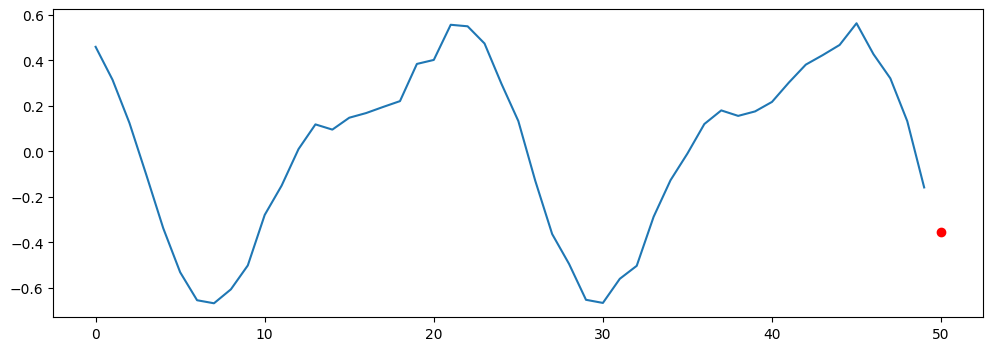

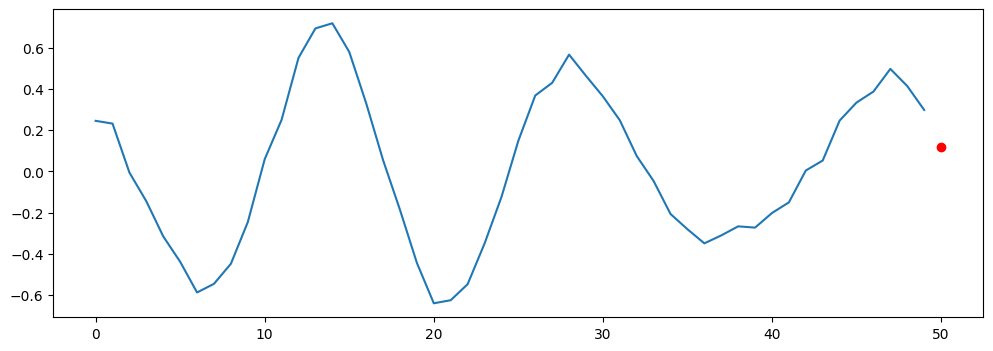

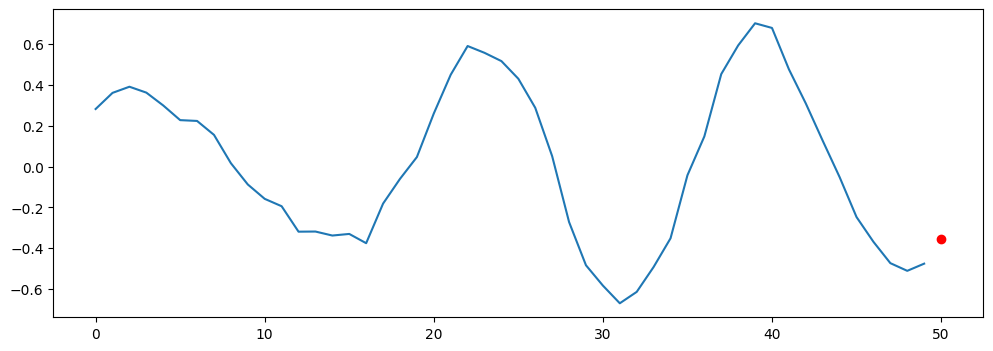

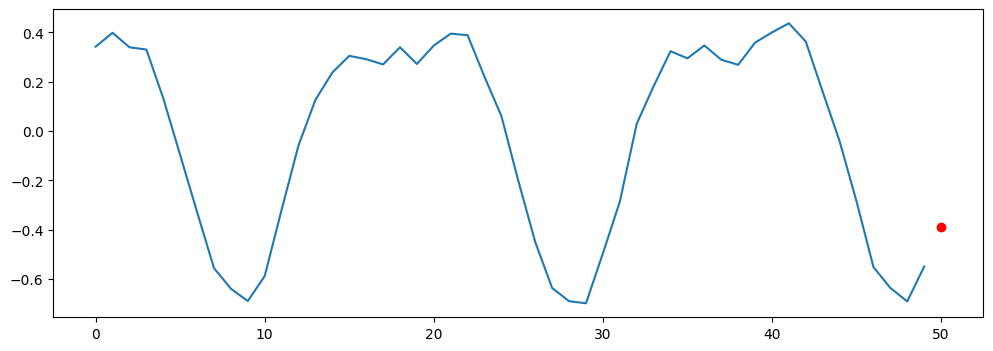

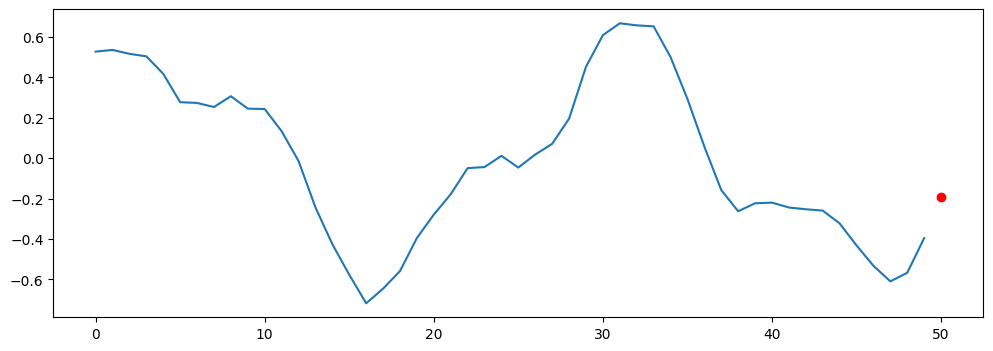

In [185]:
for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_train[i])
    plt.plot(50, y_train[i], "ro")
plt.show()

In [186]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[50, 1]),
    keras.layers.Dense(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

#no activation function, just a linear model

c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.1792 - val_loss: 0.0908
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0610 - val_loss: 0.0452
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0341 - val_loss: 0.0282
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0226 - val_loss: 0.0198
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0168 - val_loss: 0.0155
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0136 - val_loss: 0.0128
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0116 - val_loss: 0.0110
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0100 - val_loss: 0.0096
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0088 - val_loss: 0.0084
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0078 - val_loss: 0.0075
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0070 - val_loss: 0.0067
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

In [187]:
model.evaluate(X_valid, y_valid)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0040


0.0039873626083135605

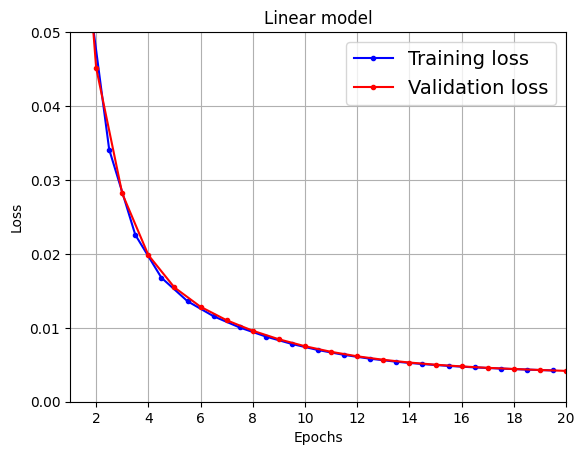

In [188]:
import matplotlib as mpl

def plot_learning_curves(loss, val_loss, title=None):
    plt.plot(np.arange(len(loss)) + 0.5, loss, "b.-", label="Training loss")
    plt.plot(np.arange(len(val_loss)) + 1, val_loss, "r.-", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
    plt.axis([1, 20, 0, 0.05])
    plt.legend(fontsize=14)
    if title:
        plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(True)

plot_learning_curves(history.history["loss"], history.history["val_loss"], title="Linear model")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


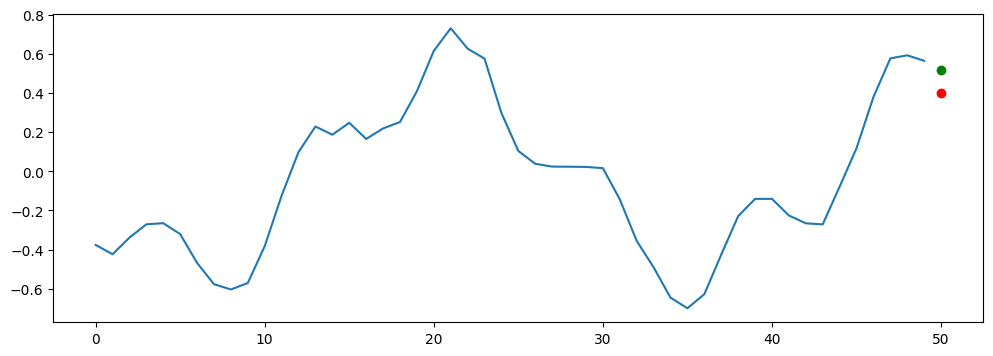

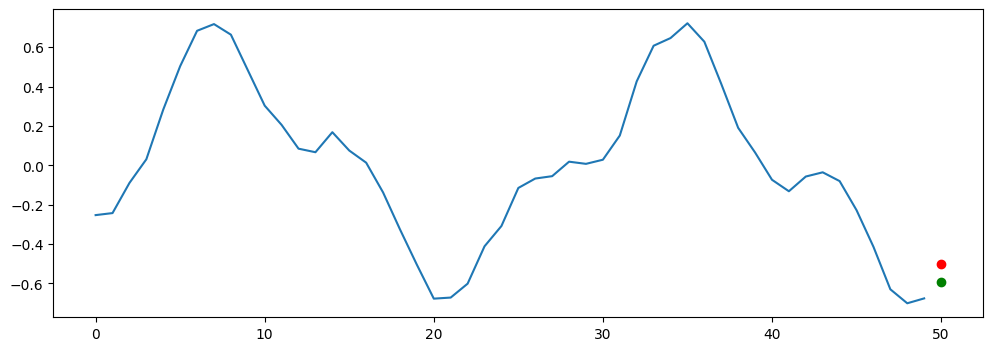

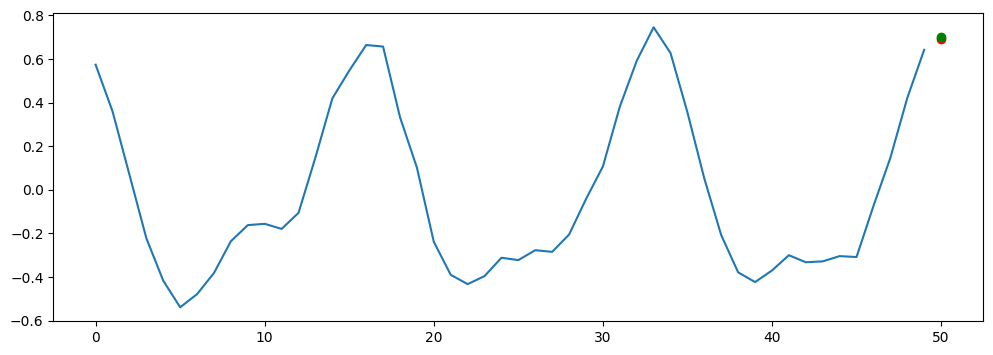

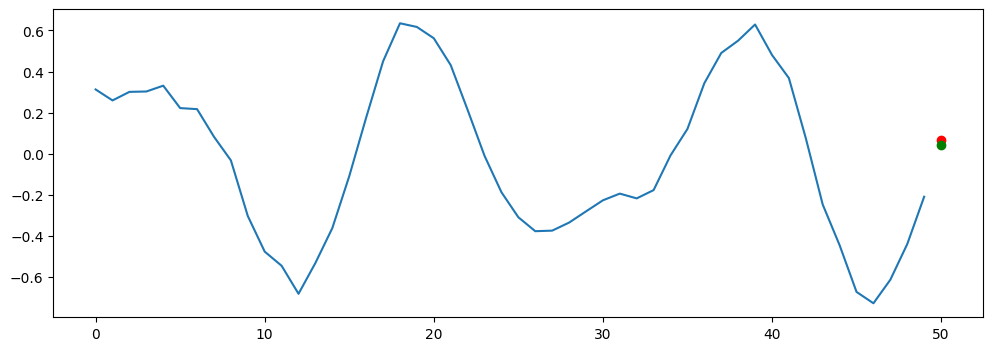

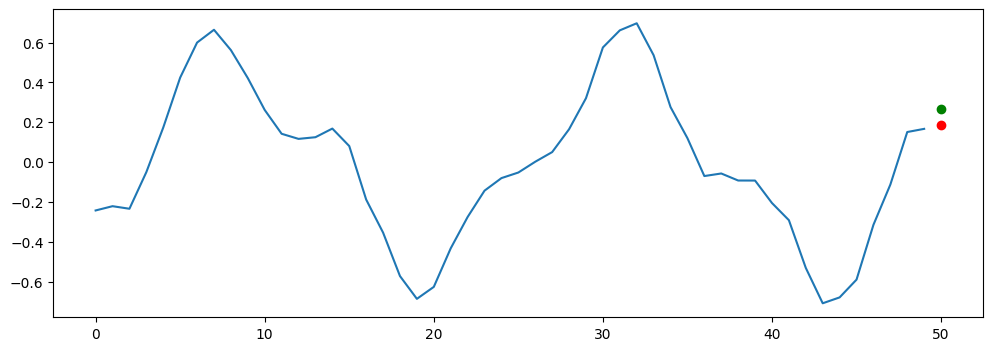

In [189]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

In [190]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(1, input_shape=[None, 1])
])

optimizer = keras.optimizers.Adam(learning_rate=0.005)
model.compile(loss="mse", optimizer=optimizer)
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

Epoch 1/20


c:\Users\nisse\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0938 - val_loss: 0.0496
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0363 - val_loss: 0.0296
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0243 - val_loss: 0.0219
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0190 - val_loss: 0.0178
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0159 - val_loss: 0.0153
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0140 - val_loss: 0.0137
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0128 - val_loss: 0.0127
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0121 - val_loss: 0.0120
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0117 - val_loss: 0.0116
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0115 - val_loss: 0.0115
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0114 - val_loss: 0.0114
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0109
SimpleRNN: 0.01093440130352974


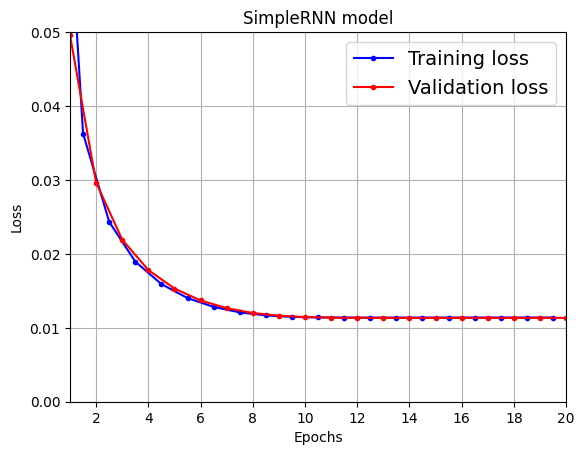

In [191]:
model.evaluate(X_valid, y_valid)

print(f"SimpleRNN: {model.evaluate(X_valid, y_valid)}")

plot_learning_curves(history.history["loss"], history.history["val_loss"], title="SimpleRNN model")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


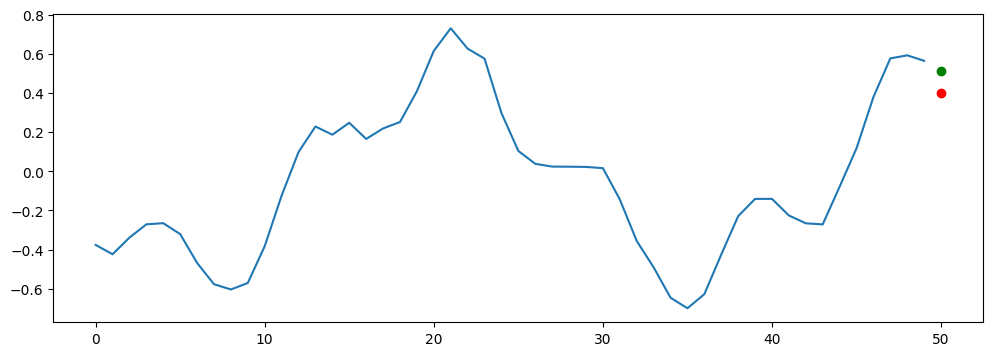

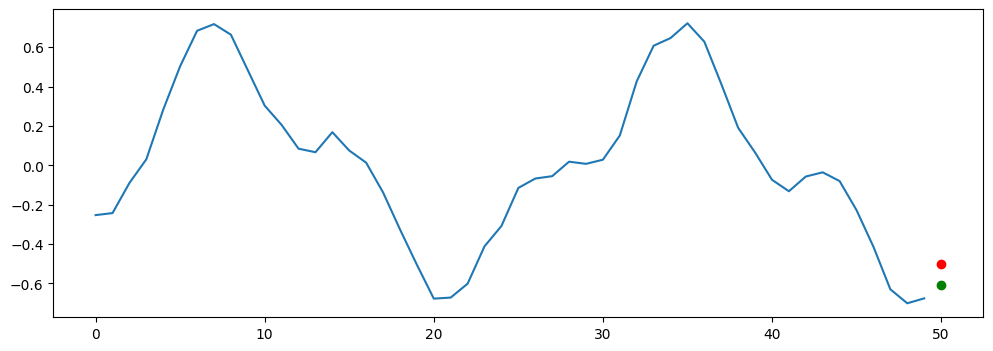

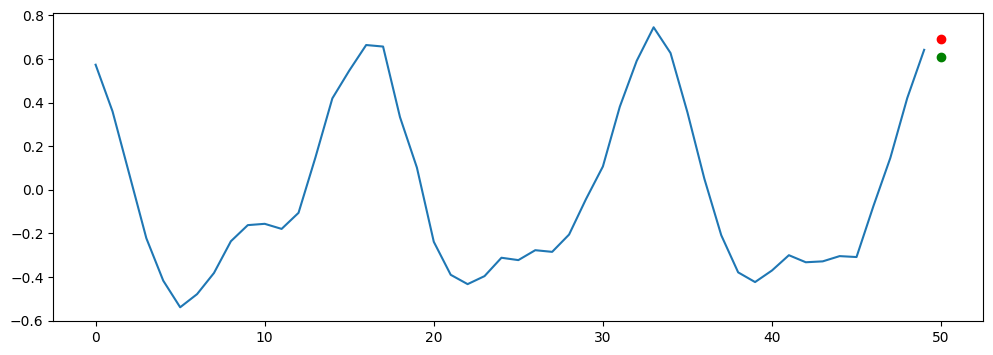

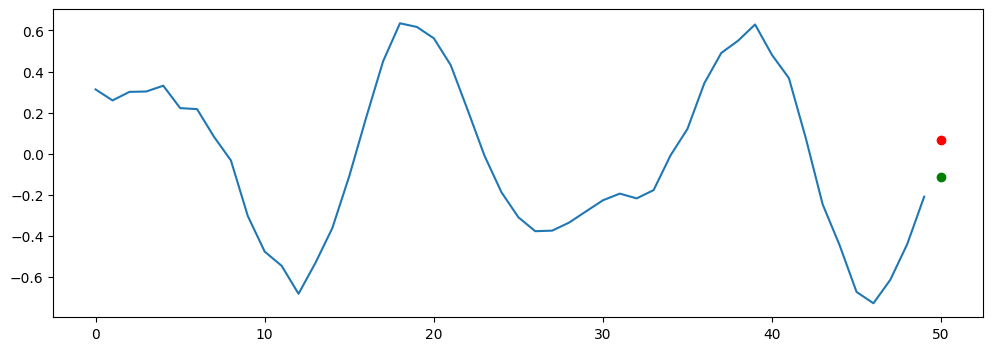

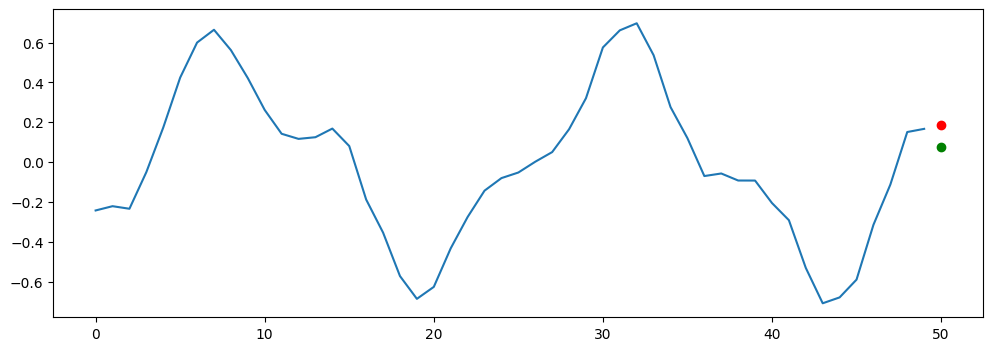

In [192]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

In [193]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(1)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - loss: 0.0654 - val_loss: 0.0093
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0056 - val_loss: 0.0061
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0048 - val_loss: 0.0053
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0043 - val_loss: 0.0048
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0039 - val_loss: 0.0044
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0037 - val_loss: 0.0041
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0036 - val_loss: 0.0040
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0034 - val_loss: 0.0038
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0033 - val_loss: 0.0036
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027


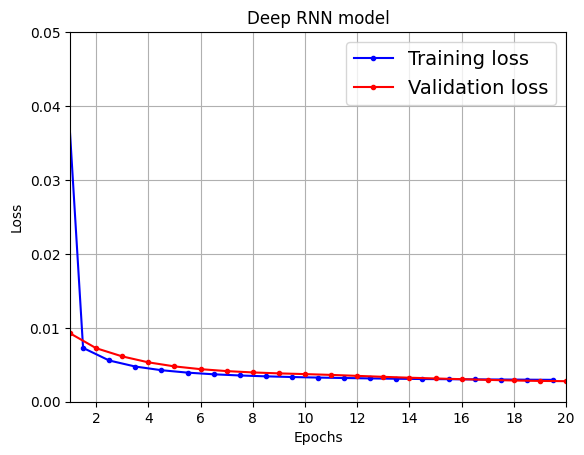

In [194]:
model.evaluate(X_valid, y_valid)

plot_learning_curves(history.history["loss"], history.history["val_loss"], title="Deep RNN model")
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


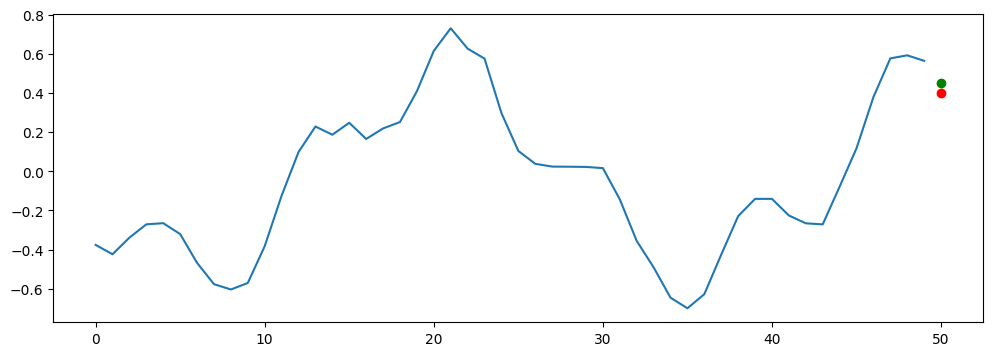

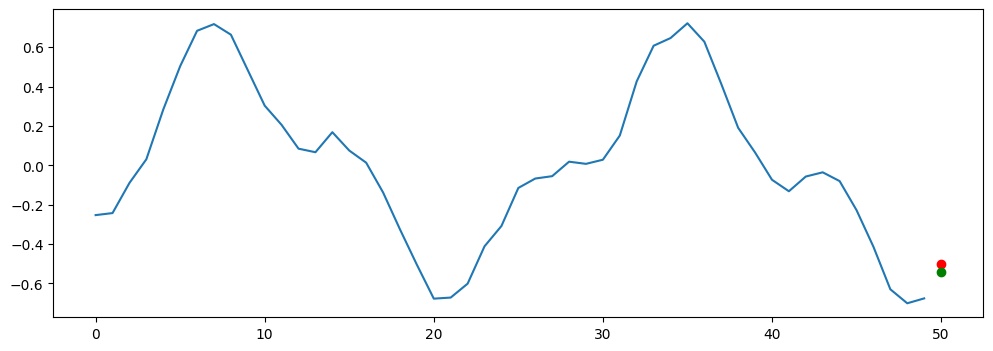

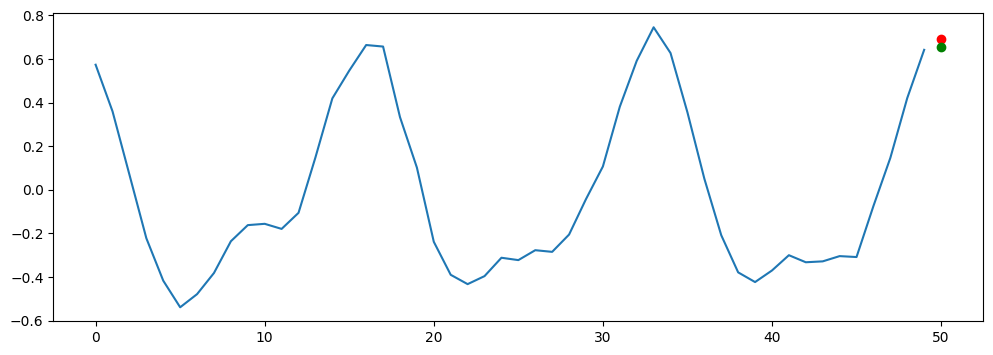

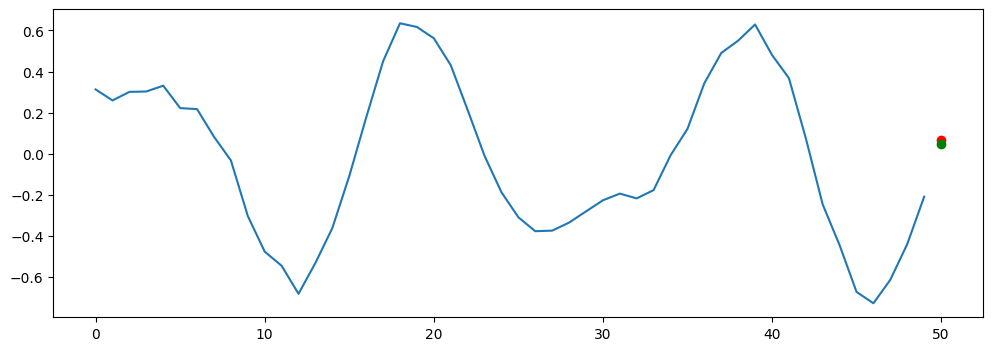

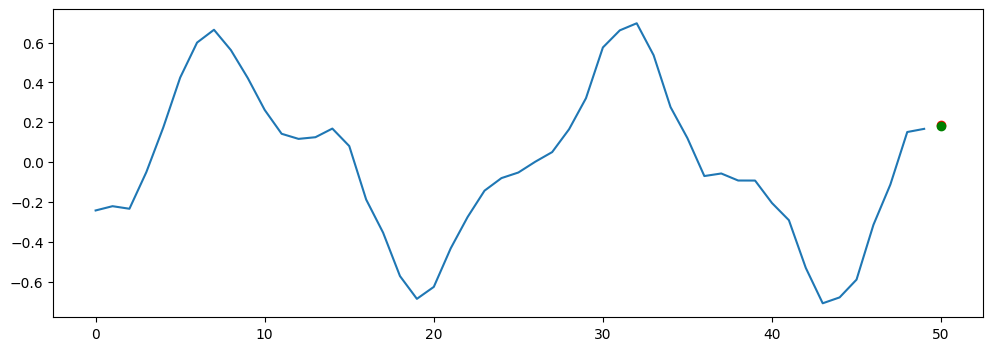

In [195]:
y_pred = model.predict(X_valid)

for i in range(5):
    plt.figure(figsize=(12, 4))
    plt.plot(X_valid[i])
    plt.plot(50, y_valid[i], "ro")
    plt.plot(50, y_pred[i], "go")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


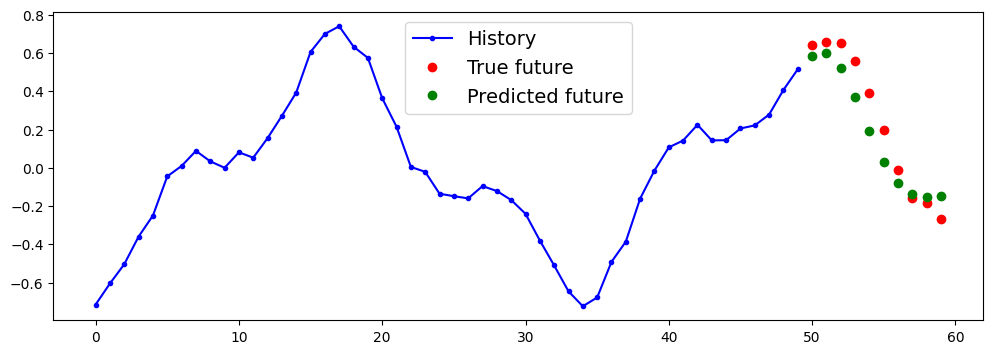

In [196]:
#Forecasting Several Steps Ahead

np.random.seed(43)

series = generate_time_series(1, n_steps + 10)
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]
X = X_new
for step_ahead in range(10):
    y_pred_one = model.predict(X[:, step_ahead:])[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_steps), X_new[0, :n_steps], "b.-", label="History")
plt.plot(np.arange(n_steps, n_steps + 10), Y_new[0], "ro", label="True future")
plt.plot(np.arange(n_steps, n_steps + 10), Y_pred[0], "go", label="Predicted future")
plt.legend(fontsize=14)

meanerror_deeprnn = np.mean((Y_new[0] - Y_pred[0])**2)


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1238 - val_loss: 0.0523
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0361 - val_loss: 0.0280
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0212 - val_loss: 0.0184
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0147 - val_loss: 0.0136
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0113 - val_loss: 0.0110
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0094 - val_loss: 0.0093
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082 - val_loss: 0.0081
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0072 - val_loss: 0.0072
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0065 - val_loss: 0.0065
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0059
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0055
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

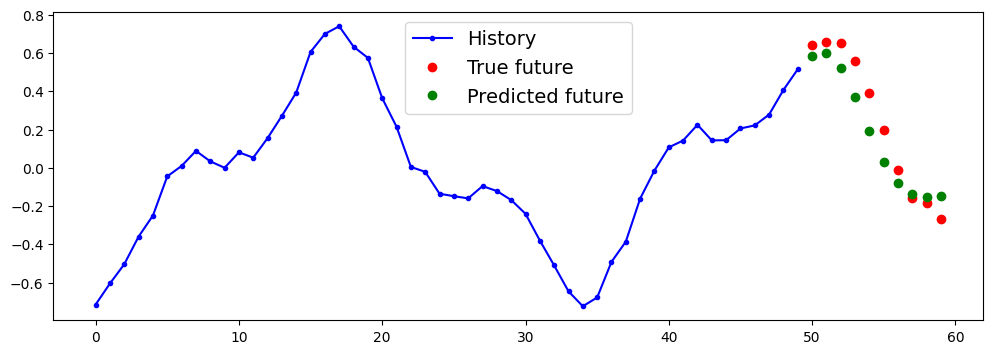

In [197]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(50, 1)),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,
                    validation_data=(X_test, y_test))


#Y_pred = X[:, n_steps:]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_steps), X_new[0, :n_steps], "b.-", label="History")
plt.plot(np.arange(n_steps, n_steps + 10), Y_new[0], "ro", label="True future")
plt.plot(np.arange(n_steps, n_steps + 10), Y_pred[0], "go", label="Predicted future")
plt.legend(fontsize=14)

y_pred_linear = model.predict(X_test)
mse_linear = np.mean((y_test - y_pred_linear)**2)

In [198]:
np.random.seed(42)

n_steps = 50
series = generate_time_series(10000, n_steps + 10)
X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 10))
for step_ahead in range(1, 10 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]
Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

np.random.seed(42)
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])

def last_time_step_mse(y_true, y_pred):
    return tf.reduce_mean(
        tf.square(y_true[:, -1] - y_pred[:, -1]))

model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=0.01), metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
                    validation_data=(X_valid, Y_valid))


Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - last_time_step_mse: 0.0413 - loss: 0.0518 - val_last_time_step_mse: 0.0262 - val_loss: 0.0381
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - last_time_step_mse: 0.0214 - loss: 0.0342 - val_last_time_step_mse: 0.0176 - val_loss: 0.0304
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - last_time_step_mse: 0.0164 - loss: 0.0294 - val_last_time_step_mse: 0.0135 - val_loss: 0.0270
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - last_time_step_mse: 0.0127 - loss: 0.0258 - val_last_time_step_mse: 0.0092 - val_loss: 0.0227
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - last_time_step_mse: 0.0099 - loss: 0.0230 - val_last_time_step_mse: 0.0079 - val_loss: 0.0208
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - last_time_step_mse: 0.0091 - loss: 0.0217 - val_last_time_step_mse: 0.0076 - val_loss: 0.0201
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - last_time_step_mse: 0.0085 - loss: 0.0208 - val_la

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


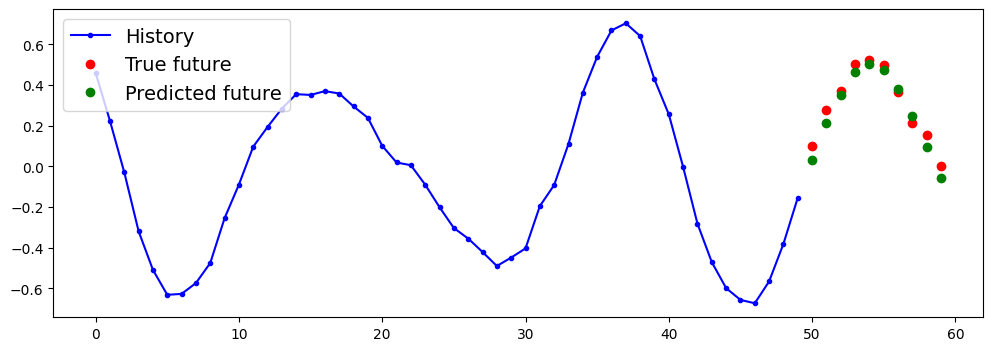

In [199]:
import numpy as np
import matplotlib.pyplot as plt

n_steps = 50
horizon = 10

# Välj ett testexempel (eller valid)
i = 0

# "History" = X_test-sekvensen (50 steg). Se till att shape blir (1, 50, 1) till modellen
X_new = X_test[i:i+1]              # shape (1, 50, 1) om X_test redan har 3D
Y_new = Y_test[i:i+1]              # shape (1, 50, 10)

# Prediktera: output shape (1, 50, 10)
Y_pred_seq = model.predict(X_new)

# Ta sista tidsstegets 10-stegs forecast
true_future = Y_new[0, -1, :]      # shape (10,)
pred_future = Y_pred_seq[0, -1, :] # shape (10,)


plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_steps), X_new[0, :n_steps, 0], "b.-", label="History")
plt.plot(np.arange(n_steps, n_steps + horizon), true_future, "ro", label="True future")
plt.plot(np.arange(n_steps, n_steps + horizon), pred_future, "go", label="Predicted future")
plt.legend(fontsize=14)
plt.show()


mse_seq2seq = np.mean((true_future - pred_future)**2)

In [200]:
print("MSE for linear model:", mse_linear)
print("MSE for deep RNN model:", meanerror_deeprnn)
print("MSE for seq2seq model:", mse_seq2seq)


MSE for linear model: 0.0038441871
MSE for deep RNN model: 0.01489038
MSE for seq2seq model: 0.0019445049016248105
